## Figures

- **Figure 2ac**: Reconstruction accuracy (cosine similarity)
- **Figure 2d**: Reconstruction accuracy as a functional of lag
- **Figure 2b**: ROI visualization
- **Figure 3**: Reconstruction accuracy and E1E2 pattern similarity

### Set up

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg
import statsmodels.stats.multitest as multi
from pymer4.models import Lmer, Lm


from pathlib import Path
import nibabel as nib
from nilearn import plotting, image

pd.set_option('display.max_columns', 60)
pd.set_option('display.precision', 5)

sns.set_style("white")
sns.set_theme(style="ticks")
sns.set(context="notebook", style="ticks", font_scale=1.5,
        rc={"lines.linewidth": 1, 'axes.labelcolor': [0, 0, 0], 'axes.edgecolor': [0, 0, 0],
            'xtick.color': [0, 0, 0], 'ytick.color': [0, 0, 0], 'text.color': [0, 0, 0],
            'axes.linewidth': 1.25, "font.size": 8, "axes.titlesize": 8, 
            "axes.labelsize": 8, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5})

import matplotlib as mpl
mpl.rc("savefig", dpi=300)
mpl.rcParams['figure.dpi'] = 300

%matplotlib inline

<Figure size 640x480 with 0 Axes>

<Figure size 600x600 with 0 Axes>

In [ ]:
# ============================================================================
# Configuration
# ============================================================================
# Data paths - update with actual paths
CLIP_DIR = Path('/path/to/nsd/reinstatement/')  
INFO_DIR = Path('/path/to/nsd/behav/')  
MNI_DIR = Path('/path/to/mni/atlas/')  

# Subject and ROI lists
SUBJECTS = range(1, 9)
CORTICAL_ROIS = ['AG', 'LOTC', 'V1', 'M1']
MTL_ROIS = ["CA1", "DGCA23", "PRC", "ERC", "PHC"]

# Color palettes
ROI_COLORS = ['#D09439', '#548B8C', '#9C8AA8', '#D1604D']
GRADIENT_LOTC = ['#548B8C', '#67A2A3', '#8CB9BA']
BINARY_MTL = ['#8B92BB', '#656EA4']
ROI_PSA = ['#548B8C', '#656EA4', '#656EA4', '#656EA4', '#656EA4', '#656EA4']


# Figure output directory
OUT_DIR = Path('/path/to/output/')  # Update with actual path
OUT_DIR.mkdir(exist_ok=True)

In [ ]:
# ============================================================================
# Helper Functions
# ============================================================================

def cosine_similarity(matrix_a, matrix_b):
    """
    Compute cosine similarity between two arrays after flattening.

    Parameters
    ----------
    matrix_a, matrix_b : array-like
        Input arrays with compatible total size.

    Returns
    -------
    float
        Cosine similarity between the flattened arrays. Returns NaN if either
        input has near-zero norm.
    """
    vector_a = np.ravel(matrix_a)
    vector_b = np.ravel(matrix_b)

    denominator = np.linalg.norm(vector_a) * np.linalg.norm(vector_b)

    if denominator < 1e-12:
        return np.nan

    return float(np.dot(vector_a, vector_b) / denominator)


def compute_cosine_permutation(embed_df, roi_id, subj_list, n_perms=1000):
    """
    Compute observed subject-level cosine similarities and a permutation null.

    For each subject, cosine similarity is computed between the actual and
    predicted embeddings for the specified ROI. The permutation null is
    generated by shuffling predicted embeddings within each subject and then
    averaging the resulting similarities across subjects.

    Parameters
    ----------
    embed_df : pandas.DataFrame
        DataFrame containing at least the columns:
        ``roi``, ``subj``, ``actual_embed``, and ``pred_embed``.
    roi_id : str or int
        ROI identifier used to subset ``embed_df``.
    subj_list : sequence
        Subject identifiers to include.
    n_perms : int, default=1000
        Number of permutations.

    Returns
    -------
    actual_means : list of float
        Mean observed cosine similarity for each subject.
    perm_distribution : list of float
        Group-level permutation null distribution.
    """
    embed_df_roi = embed_df.loc[embed_df["roi"] == roi_id].reset_index(drop=True)

    actual_means = []

    for subj in subj_list:
        sub_df = embed_df_roi.loc[embed_df_roi["subj"] == subj].reset_index(drop=True)

        actual_embed = sub_df["actual_embed"]
        pred_embed = sub_df["pred_embed"]

        subject_similarities = [
            cosine_similarity(actual, predicted)
            for actual, predicted in zip(actual_embed, pred_embed)
        ]

        actual_means.append(np.nanmean(subject_similarities))

    perm_distribution = []

    for _ in range(n_perms):
        perm_means = []

        for subj in subj_list:
            sub_df = embed_df_roi.loc[embed_df_roi["subj"] == subj].reset_index(drop=True)

            actual_embed = sub_df["actual_embed"]
            pred_embed = sub_df["pred_embed"]
            pred_shuffled = np.random.permutation(pred_embed)

            shuffled_similarities = [
                cosine_similarity(actual, predicted)
                for actual, predicted in zip(actual_embed, pred_shuffled)
            ]

            perm_means.append(np.nanmean(shuffled_similarities))

        perm_distribution.append(np.nanmean(perm_means))

    return actual_means, perm_distribution


def pointplot_err(x, y, xerr=None, yerr=None, data=None, **kwargs):
    """Custom point plot with error bars."""
    _data = []
    for _i in data.index:
        _data_i = pd.concat([data.loc[_i:_i]] * 3, ignore_index=True, sort=False)
        _row = data.loc[_i]
        if xerr is not None:
            _data_i[x] = [_row[x] - _row[xerr], _row[x], _row[x] + _row[xerr]]
        if yerr is not None:
            _data_i[y] = [_row[y] - _row[yerr], _row[y], _row[y] + _row[yerr]]
        _data.append(_data_i)
    _data = pd.concat(_data, ignore_index=True, sort=False)
    
    _ax = sns.pointplot(x=x, y=y, data=_data, ci='sd', markeredgecolor=None, **kwargs)
    return _ax

### Data Loading

In [ ]:
# ====== Load reconstructed image embedding PCs ======
# Load cortical ROI data at E1+-1 (E2 -> E1+-1)
embed_clip = pd.read_csv(CLIP_DIR / 'clip_tp1_within_beh1.csv')
embed_clip['actual_embed'] = embed_clip['actual_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip['pred_embed'] = embed_clip['pred_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip['cos_sim'] = [cosine_similarity(r1, r2) for r1, r2 in zip(embed_clip['actual_embed'], embed_clip['pred_embed'])]

# Load E1+-2, E1+-3 (E2 -> E1+-2, E2 -> E1+-3)
embed_clip_tp2 = pd.read_csv(CLIP_DIR / 'clip_tp2_within_beh1.csv')
embed_clip_tp2['actual_embed'] = embed_clip_tp2['actual_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_tp2['pred_embed'] = embed_clip_tp2['pred_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_tp2['cos_sim'] = [cosine_similarity(r1, r2) for r1, r2 in zip(embed_clip_tp2['actual_embed'], embed_clip_tp2['pred_embed'])]

embed_clip_tp3 = pd.read_csv(CLIP_DIR / 'clip_tp3_within_beh1.csv')
embed_clip_tp3['actual_embed'] = embed_clip_tp3['actual_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_tp3['pred_embed'] = embed_clip_tp3['pred_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_tp3['cos_sim'] = [cosine_similarity(r1, r2) for r1, r2 in zip(embed_clip_tp3['actual_embed'], embed_clip_tp3['pred_embed'])]

# Load cortical ROI data for current item (E2 -> E2)
embed_clip_n0 = pd.read_csv(CLIP_DIR / 'clip_n0_within_beh1.csv')
embed_clip_n0['actual_embed'] = embed_clip_n0['actual_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_n0['pred_embed'] = embed_clip_n0['pred_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_n0['cos_sim'] = [cosine_similarity(r1, r2) for r1, r2 in zip(embed_clip_n0['actual_embed'], embed_clip_n0['pred_embed'])]

# Load MTL ROI data
embed_clip_mtl = pd.read_csv(CLIP_DIR / 'clip_tp1_within_beh1_mtl_0525.csv')
embed_clip_mtl['actual_embed'] = embed_clip_mtl['actual_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_mtl['pred_embed'] = embed_clip_mtl['pred_embed'].apply(lambda x: np.fromstring(x[1:-1], sep=','))
embed_clip_mtl['cos_sim'] = [cosine_similarity(r1, r2) for r1, r2 in zip(embed_clip_mtl['actual_embed'], embed_clip_mtl['pred_embed'])]

In [ ]:
# Load subject-by-ROI context reinstatement accuracy
corr_clip = pd.concat([
    pd.read_csv(CLIP_DIR / f'clip_ridge_tp{i}_within_beh1.csv').assign(tp=i)
    for i in range(1, 4)
], ignore_index=True)

In [ ]:
# Load pattern similarity data
ps_mtl = pd.read_csv(INFO_DIR.parent / 'main/item_MTL_all.csv')
ps_cor = pd.read_csv(INFO_DIR.parent / 'main/item_cortical_all.csv')
# Load behavioral info
item_info = pd.read_csv(INFO_DIR / 'nsdmain_cr_hit.csv')
# Filter out same-session and same-run pairs
df_psa = item_info[~((item_info['FIRST_SESS'] == item_info['SECOND_SESS'])& 
                  (item_info['FIRST_RUN'] == item_info['SECOND_RUN']))].reset_index(drop=True)

### Stats

In [ ]:
clip_roi_n0 = {roi: [] for roi in CORTICAL_ROIS}
clip_roi_n0_perm = {roi: [] for roi in CORTICAL_ROIS}
clip_roi_n0_pvals = {roi: [] for roi in CORTICAL_ROIS}


for roi in CORTICAL_ROIS:
    clip_roi_mean, clip_roi_perm = compute_cosine_permutation(embed_clip_n0, roi, SUBJECTS)
    clip_roi_n0[roi] = clip_roi_mean
    clip_roi_n0_perm[roi] = clip_roi_perm
    clip_perm_p = (np.sum(clip_roi_perm >= np.mean(clip_roi_mean)) + 1) / (len(clip_roi_perm) + 1)
    clip_roi_n0_pvals[roi] = clip_perm_p

In [ ]:
clip_roi_n1 = {roi: [] for roi in CORTICAL_ROIS}
clip_roi_n1_perm = {roi: [] for roi in CORTICAL_ROIS}
clip_roi_n1_pvals = {roi: [] for roi in CORTICAL_ROIS}

for roi in CORTICAL_ROIS:
    clip_roi_mean, clip_roi_perm = compute_cosine_permutation(embed_clip, roi, SUBJECTS)
    clip_roi_n1[roi] = clip_roi_mean
    clip_roi_n1_perm[roi] = clip_roi_perm
    clip_perm_p = (np.sum(clip_roi_perm >= np.mean(clip_roi_mean)) + 1) / (len(clip_roi_perm) + 1)
    clip_roi_n1_pvals[roi] = clip_perm_p

In [ ]:
# mixed-effects model for E1E2 similarity to LOTC reinstatement
model_psa = pd.DataFrame()
embed_clip_roi = embed_clip.loc[embed_clip.roi=="LOTC"].reset_index(drop=True)

# mixed-effects model for LOTC similarity to LOTC reinstatement
roi = "LOTC"
ps_cor_roi = ps_cor.loc[ps_cor.roi==roi].reset_index(drop=True)
df_psa['r12_item'] = np.arctanh(ps_cor_roi['r']) - np.arctanh(ps_cor_roi['r12']) #item-specific pattern similarity
clip_df_comb = pd.merge(df_psa, embed_clip_roi[['subj', 'nsdid', 'roi', 'actual_embed', 'pred_embed', 'cos_sim']], 
                             left_on=['SUBJECT', '73KID'], right_on=['subj', 'nsdid'],
                             how='left').dropna(subset=['r12_item']).reset_index(drop=True)

In [ ]:
mod_roi = Lmer("cos_sim ~ r12_item + LAG0 + LAG1 + (1|SUBJECT)", 
               data=clip_df_comb.dropna())
mod_roi.fit()
mod_out = mod_roi.coefs[['Estimate', '2.5_ci', '97.5_ci', 'SE', 'P-val', 'Sig']][1:2]
mod_out['roi'] = "LOTC"
model_psa = pd.concat([model_psa, mod_out], ignore_index=True)

In [ ]:
# mixed-effects model for MTL ROIs to LOTC reinstatement
for mtl_roi in MTL_ROIS:
    ps_mtl_roi = ps_mtl.loc[ps_mtl.roi==mtl_roi].reset_index(drop=True)
    df_psa['r12_item'] = np.arctanh(ps_mtl_roi['r']) - np.arctanh(ps_mtl_roi['r12'])
    clip_df_comb = pd.merge(df_psa, embed_clip_roi[['subj', 'nsdid', 'roi', 'actual_embed', 'pred_embed', 'cos_sim']], 
                             left_on=['SUBJECT', '73KID'], right_on=['subj', 'nsdid'],
                             how='left').dropna(subset=['r12_item']).reset_index(drop=True)
    mod_roi = Lmer("cos_sim ~ r12_item + LAG0 + LAG1 + (1|SUBJECT)", 
               data=clip_df_comb.dropna())
    mod_roi.fit()
    mod_out = mod_roi.coefs[['Estimate', '2.5_ci', '97.5_ci', 'SE', 'P-val', 'Sig']][1:2]
    mod_out['roi'] = mtl_roi
    model_psa = pd.concat([model_psa, mod_out], ignore_index=True)

In [ ]:
# complementary to mixed-effects model: median split hippocampal similarity 

clip_corr_by_lag = []

for mtl_roi in ["CA1", "DGCA23"]:

    ps_mtl_roi = ps_mtl.loc[ps_mtl["roi"] == mtl_roi].reset_index(drop=True)

    df_psa_roi = df_psa.copy()
    df_psa_roi["r12_item"] = (
        np.arctanh(ps_mtl_roi["r"])
        - np.arctanh(ps_mtl_roi["r12"])
    )

    clip_df_comb = pd.merge(
        df_psa_roi,
        embed_clip_roi[
            ["subj", "nsdid", "roi", "actual_embed", "pred_embed", "cos_sim"]
        ],
        left_on=["SUBJECT", "73KID"],
        right_on=["subj", "nsdid"],
        how="left",
    ).dropna(subset=["r12_item"]).reset_index(drop=True)

    clip_df_comb["r12_group"] = pd.NA

    for subj in SUBJECTS:
        subj_mask = clip_df_comb["SUBJECT"] == subj

        median_val = np.nanmedian(
            clip_df_comb.loc[subj_mask, "r12_item"]
        )

        clip_df_comb.loc[
            subj_mask & (clip_df_comb["r12_item"] <= median_val),
            "r12_group",
        ] = 1

        clip_df_comb.loc[
            subj_mask & (clip_df_comb["r12_item"] > median_val),
            "r12_group",
        ] = 2

    for subj in SUBJECTS:
        subj_mask = clip_df_comb["SUBJECT"] == subj

        for group in [1, 2]:
            group_mask = subj_mask & (clip_df_comb["r12_group"] == group)

            cos = np.nanmean(
                clip_df_comb.loc[group_mask, "cos_sim"]
            )

            clip_corr_by_lag.append(
                {
                    "subj": subj,
                    "roi": mtl_roi,
                    "group": group,
                    "cos": cos,
                }
            )

clip_corr_by_lag = pd.DataFrame(clip_corr_by_lag)

### Figures

#### Fig. 2a - Reconstruction of current item 

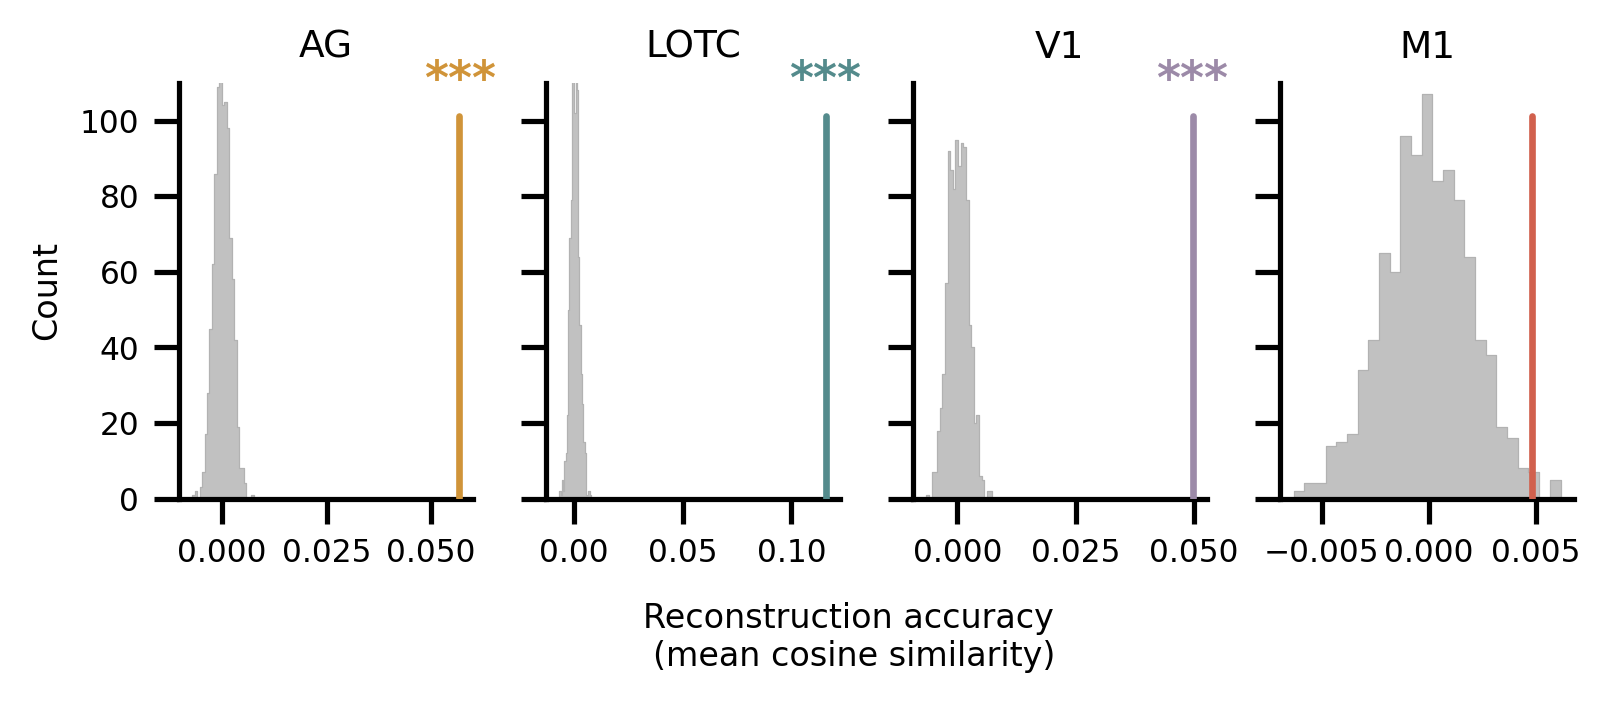

In [ ]:
f, axes = plt.subplots(1, 4, figsize=(6, 1.8), sharex=False, sharey=True)
f.subplots_adjust(wspace=0.25)
axes = axes.flatten()
bin_num = 25

for ax, roi_n in zip(axes, range(4)):
    roi = CORTICAL_ROIS[roi_n]
    sns.histplot(
        data=clip_roi_n0_perm[roi],
        ax=ax,
        bins=bin_num,
        color="#b2b2b2",
        element='step',
        alpha=.8,
        linewidth=.3,
        kde=0
    )
    ax.axvline(x = np.mean(clip_roi_n0[roi]),
            linewidth=1.6, ymin=0,ymax=.92, 
            linestyle = '-', color=ROI_COLORS[roi_n], zorder=100)
    ax.set_title(f"{roi}", size=9)
    ax.set(ylim=[0,110]
           )
    sns.despine()

f.text(0.281, 0.86, "***", ha="center", fontsize=11, weight='heavy', color=ROI_COLORS[0])
f.text(0.484, 0.86, "***", ha="center", fontsize=11, weight='heavy', color=ROI_COLORS[1])
f.text(0.688, 0.86, "***", ha="center", fontsize=11, weight='heavy', color=ROI_COLORS[2])

f.text(0.5, -.2, "Reconstruction accuracy \n(mean cosine similarity)", ha="center", fontsize=8)

plt.savefig('fig2_1.svg', dpi=300, bbox_inches = "tight")

#### Fig.2c - Reconstruction of temporal context images

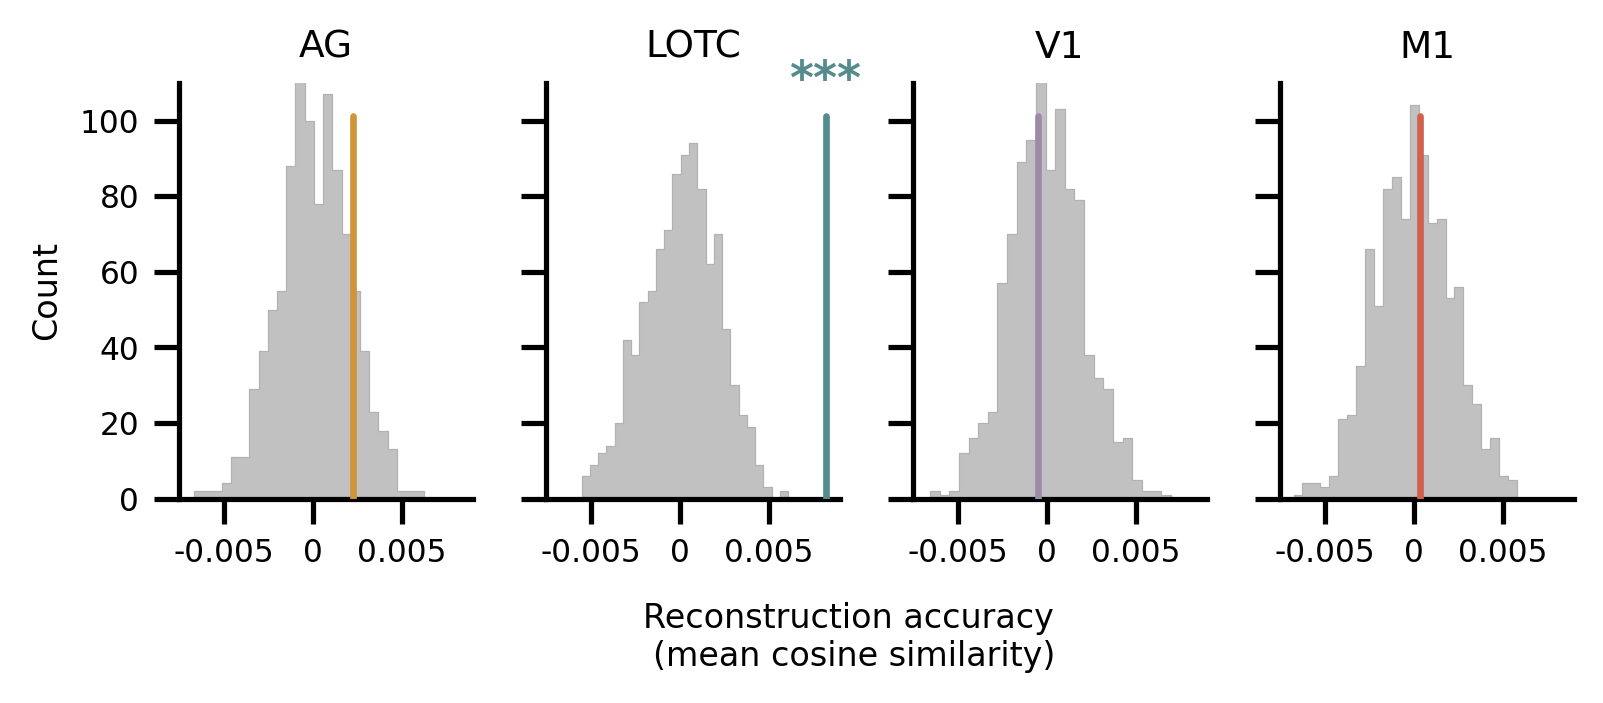

In [ ]:
f, axes = plt.subplots(1, 4, figsize=(6, 1.8), sharex=True, sharey=True)
f.subplots_adjust(wspace=0.25)
axes = axes.flatten()
bin_num = 25

for ax, roi_n in zip(axes, range(4)):
    roi = CORTICAL_ROIS[roi_n]
    sns.histplot(
        data=clip_roi_n1_perm[roi],
        ax=ax,
        bins=bin_num,
        color="#b2b2b2",
        element='step',
        alpha=.8,
        linewidth=.3,
        kde=0
    )
    ax.axvline(x = np.mean(clip_roi_n1[roi]),
            linewidth=1.6, ymin=0,ymax=.92, 
            linestyle = '-', color=ROI_COLORS[roi_n], zorder=100)
    ax.set_title(f"{roi}", size=9)
    ax.set(
        ylim=[0,110], 
    )
    sns.despine()

f.text(0.484, 0.86, "***", ha="center", fontsize=11, weight='heavy', color=ROI_COLORS[1])

f.text(0.5, -.2, "Reconstruction accuracy \n(mean cosine similarity)", ha="center", fontsize=8)

plt.savefig('fig2_2.svg', dpi=300, bbox_inches = "tight")

#### Fig. 2d - Reconstruction by distance to E1 

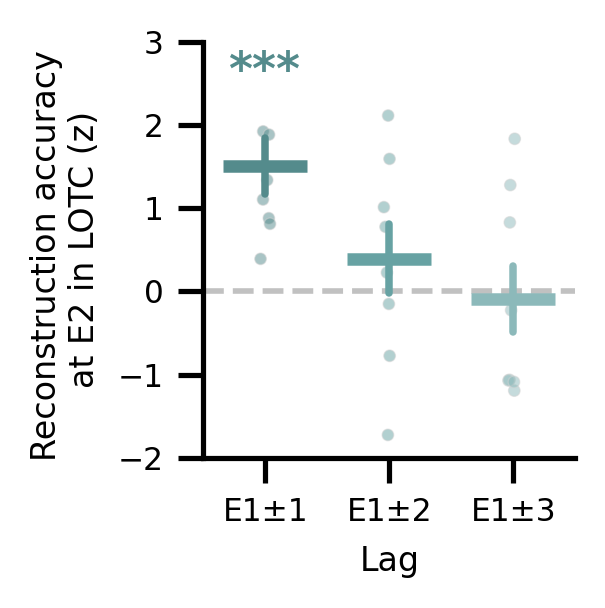

In [ ]:
f, ax1 = plt.subplots(1, 1, figsize=(1.6, 1.8))
sns.pointplot(x="tp", y="z_score", 
              data = corr_clip.loc[corr_clip.roi=="LOTC"], 
              ax=ax1, ci=68, join=False, palette=GRADIENT_LOTC,
              marker="_", markersize=20, markeredgewidth=3
            )
sns.stripplot(x="tp", y="z_score", 
              data = corr_clip.loc[corr_clip.roi=="LOTC"], 
              ax = ax1, s=2.8, alpha=.5, palette = GRADIENT_LOTC,
              jitter = .05, zorder = 1,  linewidth=.3, edgecolor="lightgray")

ax1.legend_ = None
ax1.set(ylim = [-2, 3],
        xticklabels = ["E1±1", "E1±2", "E1±3"],
        ylabel="Reconstruction accuracy \nat E2 in LOTC (z)", xlabel="Lag")
ax1.axhline(y = 0, linewidth=1.35, alpha=.8,
            linestyle = '--', color="#b2b2b2", zorder=1)
sns.despine()
f.text(0.2515, 0.8, "***", ha="center", fontsize=11, weight='heavy', color=ROI_COLORS[1])

plt.savefig('fig2_3.svg', dpi=300, bbox_inches = "tight")

#### Fig.3 - Hippocampal similarity and temporal context reinstatement in LOTC

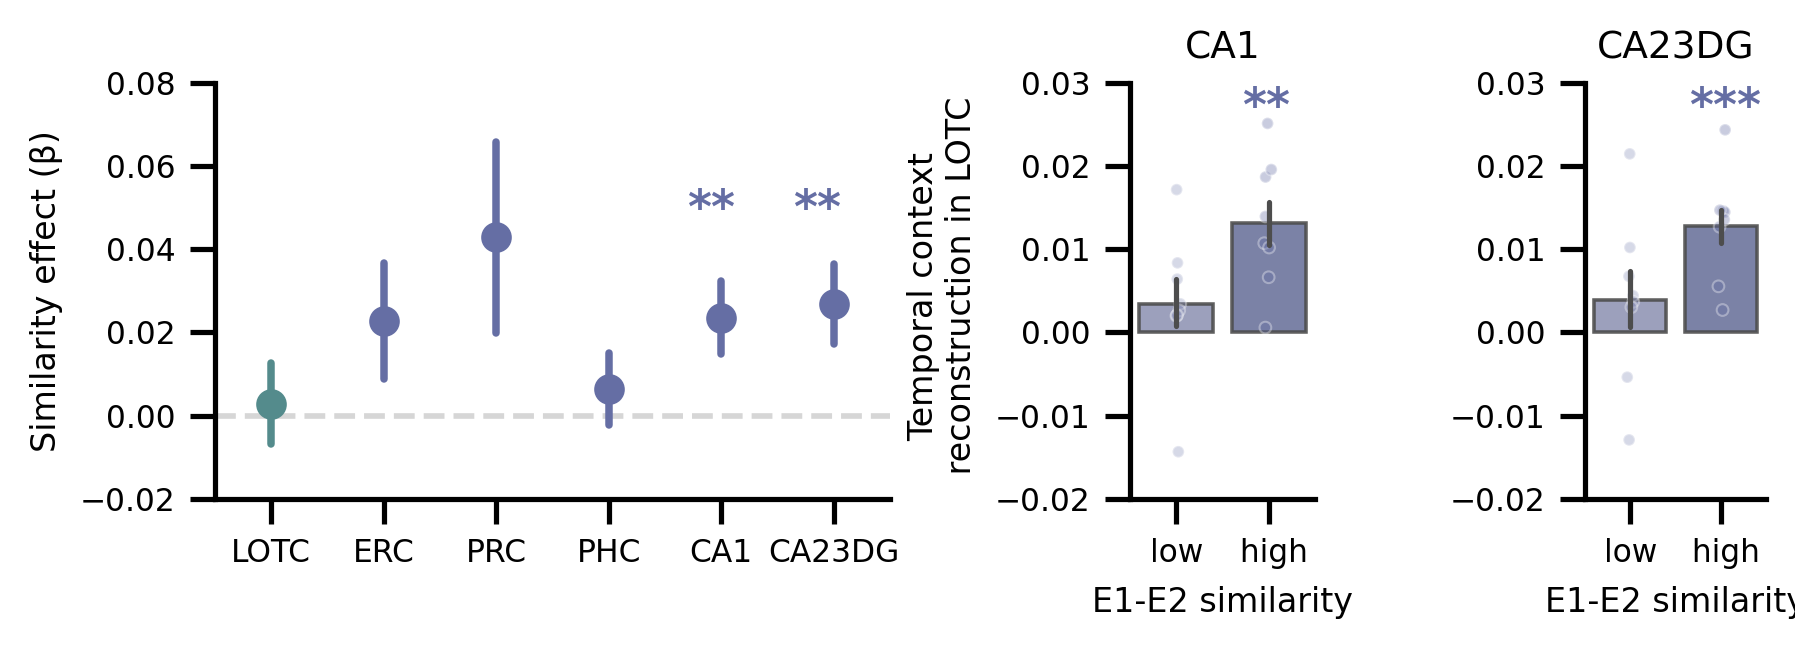

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6.8, 1.8), 
                            sharey=False, sharex=False,
                            gridspec_kw = {'width_ratios':[2.8, 1, 1]})
f.subplots_adjust(wspace=0.55)

# panel 1: mixed-effects model coefs across ROIs
pointplot_err(x="roi", y="Estimate", yerr="SE", ax=ax1,
              data = model_psa, order = ['LOTC', 'ERC', 'PRC', 'PHC', 'CA1', 'DGCA23'],
              palette = ROI_PSA, markersize=6)
ax1.legend_ = None
ax1.set(
    ylim = [-.02, .08],
    xticklabels = ['LOTC', 'ERC', 'PRC', 'PHC', 'CA1', 'CA23DG'],
    ylabel="Similarity effect (β)", xlabel="")
ax1.axhline(y = 0, linewidth=1.35, alpha=.8,
            linestyle = '--', color="#cccccc", zorder=1)
sns.despine()

# panel 2: high vs low comparison for CA1 and CA23DG
sns.barplot(x="group", y="cos", 
            data = clip_corr_by_lag.loc[clip_corr_by_lag['roi']=="CA1"],  
              ax=ax2, ci=68, 
            errwidth=1.25,linewidth=.85,edgecolor=".3",alpha=.9,errcolor=".3",
              palette=BINARY_MTL, 
            )
sns.stripplot(x="group", y="cos", 
              data = clip_corr_by_lag.loc[clip_corr_by_lag['roi']=="CA1"],  
              s=2.8, ax = ax2, alpha=.35, palette=BINARY_MTL, 
              jitter = .05, zorder = 1,  linewidth=.5, edgecolor="white")
ax2.set(
    ylim = [-.02, .03],
    xticklabels = ["low", " high"],
    ylabel="Temporal context \n reconstruction in LOTC", xlabel="E1-E2 similarity")
ax2.set_box_aspect(4.5/len(ax2.patches))
ax2.set_title("CA1", size=9)


sns.barplot(x="group", y="cos", 
            data = clip_corr_by_lag.loc[clip_corr_by_lag['roi']=="DGCA23"],  
              ax=ax3, ci=68, 
            errwidth=1.25,linewidth=.85,edgecolor=".3",alpha=.9,errcolor=".3",
              palette=BINARY_MTL, 
            )
sns.stripplot(x="group", y="cos", 
              data = clip_corr_by_lag.loc[clip_corr_by_lag['roi']=="DGCA23"],  
              s=2.8, ax = ax3, alpha=.35, palette=BINARY_MTL, 
              jitter = .05, zorder = 1,  linewidth=.5, edgecolor="white")
ax3.set(
    ylim = [-.02, .03],
    xticklabels = ["low", " high"],
    ylabel="", xlabel="E1-E2 similarity")
ax3.set_box_aspect(4.6/len(ax2.patches))
ax3.set_title("CA23DG", size=9)


f.text(0.368, 0.62, "**", ha="center", fontsize=11, weight='heavy', color=ROI_PSA[-1])
f.text(0.42, 0.62, "**", ha="center", fontsize=11, weight='heavy', color=ROI_PSA[-1])

f.text(0.64, 0.81, "**", ha="center", fontsize=11, weight='heavy', color=ROI_PSA[-1])
f.text(0.865, 0.81, "***", ha="center", fontsize=11, weight='heavy', color=ROI_PSA[-1])

plt.savefig('fig3.svg', dpi=300, bbox_inches = "tight")